In [1]:
import os
import sys
import numpy as np

sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))) + "/src")

from visualizer import plot_ring_state
from ring_attractor import RingAttractor, CosineKernelInitStrategy
from nonlinearity import ReLUNonlinearity
from ring_attractor import RingAttractorSimulator

<PolarAxes: >

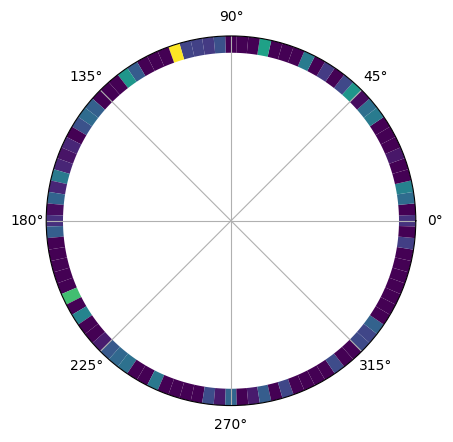

In [2]:
rng = np.random.default_rng(42)
ring_size = 100

attractor = RingAttractor(
    ring_size,
    CosineKernelInitStrategy(j0=-2.0, j1=4.0),
    ReLUNonlinearity(),
    rng   
)

plot_ring_state(attractor)

<PolarAxes: >

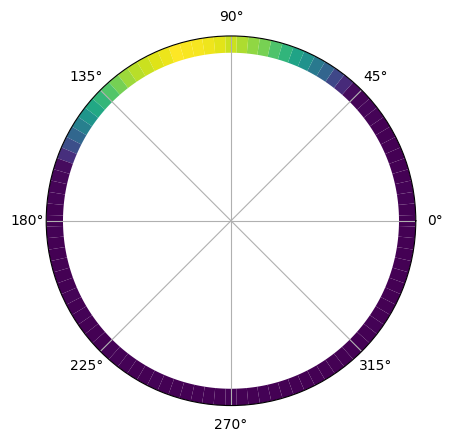

In [3]:
def create_cue_input(attractor: RingAttractor, theta_target: float, amplitude: float = 1) -> np.ndarray:
    return amplitude * np.cos(attractor.neuron_angles - theta_target)

simulator = RingAttractorSimulator(attractor, 0.01, 10, 0.1, rng) # Some random parameters

for i in range(100):
    cue_input = create_cue_input(attractor, np.pi / 2)
    simulator.perform_single_step(cue_input)

plot_ring_state(attractor)